# Modelo de Predição

Para treinamento:
- Resultado com grid search
    - Utilizado GridSearch.ipynb
- Resultado com baesyan search
    - Utilizado BayesianOptimization.ipynb
- Resultado com teste empirico
- O modelo utilizado é XGBRegressor.
- Foram testadas os hiperparametros:
    - n_estimators
    - learning_rate
    - max_depth
    - subsample
    - min_child_weight
    - colsample_bynode
    - colsample_bytree
    - colsample_bylevel
    - num_parallel_tree
    - tree_method
    - max_delta_step
    - gamma
    - reg_alpha
    - reg_lambda
    - random_state
    


- Os seguintes não foram eficazes, por piorar o modelo ou por causar pouco efeito:
    - colsample_bynode
    - colsample_bytree
    - colsample_bylevel
    - tree_method
    - max_delta_step
    - gamma
    - reg_alpha
    - reg_lambda


- Os hiperparâmetros que não deram reultados empiricamente foram desconsiderados para Grid Serach e Otimização Bayesiana

- O hiperparametro random_state não causou efeito mas foi mantido para manter a reprodutibilidade

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.model_selection import learning_curve

In [24]:
taxi_clima = pd.read_csv('C:/Users/jhrat/Desktop/Mestrado BCC/Tópicos em Engenharia de Software/Projeto/taxi_clima.csv')
taxiTreino_clima = pd.read_csv('C:/Users/jhrat/Desktop/Mestrado BCC/Tópicos em Engenharia de Software/Projeto/taxiTreino_clima.csv')

In [25]:
# Função para agrupar os dados por hora
def preparar_dados(df):
    # Garante que a coluna de data é datetime
    df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
    
    # Arredonda a hora
    df['data_hora'] = df['lpep_pickup_datetime'].dt.floor('H')
    
    # Agrupa por hora
    df_agrupado = df.groupby('data_hora').agg(
        demanda_corridas=('lpep_pickup_datetime', 'count'),
        temperatura=('temperatura [C°]', 'mean'),
        umidade=('umidade relativa [%]', 'mean'),
        precipitacao=('precipitação acumulada em 1 hora [mm]', 'mean'),
        vento_vel=('velocidade do vento [mph]', 'mean'),
        feriado_fds=('feriado/fim de semana', 'max')
    ).reset_index()
    
    # Criar variáveis de tempo
    df_agrupado['hora_do_dia'] = df_agrupado['data_hora'].dt.hour
    df_agrupado['dia_da_semana'] = df_agrupado['data_hora'].dt.dayofweek
    df_agrupado['mes'] = df_agrupado['data_hora'].dt.month
    
    # Remove qualquer linha que tenha ficado com dados nulos no clima
    df_agrupado = df_agrupado.dropna()
    
    return df_agrupado

In [26]:
#Conta a quantidade de linhas antes e depois do agrupamento
quantidade_linhas_taxiTreino = len(taxiTreino_clima)
quantidade_linhas_taxi = len(taxi_clima)

# Realiza o agrupamento do dados
treino_agg = preparar_dados(taxiTreino_clima)
teste_agg = preparar_dados(taxi_clima)

quantidade_linhas_treino = len(treino_agg)
quantidade_linhas_teste = len(teste_agg)

linhas_final_treino = quantidade_linhas_taxiTreino - quantidade_linhas_treino
linhas_final_teste = quantidade_linhas_taxi - quantidade_linhas_teste

print(f"O dataset de TREINO tem {quantidade_linhas_taxiTreino} linhas.")
print(f"Após o agrupamento: {quantidade_linhas_treino} linhas.")
print(f"Foram retidaras {linhas_final_treino} linhas.")
print(f"===========================================================")
print(f"===========================================================")
print(f"O dataset de TESTE tem {quantidade_linhas_taxi} linhas.")
print(f"Após o agrupamento: {quantidade_linhas_teste} linhas.")
print(f"Foram retidaras {linhas_final_teste} linhas.")

O dataset de TREINO tem 734172 linhas.
Após o agrupamento: 8758 linhas.
Foram retidaras 725414 linhas.
O dataset de TESTE tem 640265 linhas.
Após o agrupamento: 7985 linhas.
Foram retidaras 632280 linhas.


In [27]:
# Define variáveis e alvo
features = [
    'temperatura',
    'umidade',
    'precipitacao',
    'vento_vel', 
    'feriado_fds',
    'hora_do_dia',
    'dia_da_semana',
    'mes'
]

X_train = treino_agg[features]
y_train = treino_agg['demanda_corridas']

X_test = teste_agg[features]
y_test = teste_agg['demanda_corridas']

In [28]:
# Treina o modelo

# Seletor de modelo
    # 1 -> Empirico
    # 2 -> Aproximação Bayesiana
    # 3 -> Grid Search
modelo=1

if modelo == 1:
    # Modelo empirico
    modelo_xgb = XGBRegressor(
        n_estimators=550,
        learning_rate=0.005,
        max_depth=8,
        subsample=0.3,
        min_child_weight=5,
        #colsample_bynode=1,
        #colsample_bytree=1,
        #colsample_bylevel=1,
        #num_parallel_tree=1,
        #tree_method='hist',
        #max_delta_step=200,
        #gamma=200,
        #reg_alpha=200,
        #reg_lambda=200,
        random_state=15
    )

elif modelo == 2:
    # Modelo indicado pela aproximação Bayesiana
    modelo_xgb = XGBRegressor(
        n_estimators=492,
        learning_rate=0.00802122778072089,
        max_depth=6,
        subsample=0.772640650610975,
        min_child_weight=15,
        num_parallel_tree=11,
        random_state=15
    )


elif modelo == 3:
    # Grid Serach
    modelo_xgb = XGBRegressor(
        n_estimators=700,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.2,
        min_child_weight=7,
        num_parallel_tree=4,
        random_state=15
    )





# Realiza o treinamento
modelo_xgb.fit(X_train, y_train)

# Faz a previsão
teste_agg['previsao_demanda'] = modelo_xgb.predict(X_test)

# Arredonda a previsão, pois quantidade de corridas são inteiros
teste_agg['previsao_demanda'] = np.round(teste_agg['previsao_demanda'])

In [29]:
teste_agg.head(5)

,data_hora,demanda_corridas,temperatura,umidade,precipitacao,vento_vel,feriado_fds,hora_do_dia,dia_da_semana,mes,previsao_demanda
0,2023-01-01 00:00:00,60,12.121000,91.113667,0.672163,2.491667,1,0,6,1,52.0
1,2023-01-01 01:00:00,58,11.670000,92.378276,0.816911,6.067241,1,1,6,1,35.0
2,2023-01-01 02:00:00,52,11.605385,89.604615,0.666249,7.784615,1,2,6,1,28.0
3,2023-01-01 03:00:00,38,11.110000,92.860000,0.000000,5.750000,1,3,6,1,24.0
4,2023-01-01 04:00:00,23,11.596957,85.665652,0.000000,8.600000,1,4,6,1,21.0


In [30]:
# Performance

# Dados reais
valores_reais = y_test

# Resultado da previsão
valores_previstos = teste_agg['previsao_demanda']

# Calculo do Erro Médio Absoluto (MAE)
erro_medio = mean_absolute_error(valores_reais, valores_previstos)

# Calculo de R2
r2 = r2_score(valores_reais, valores_previstos)

# Calculo do MSE (Mean Squared Error)
mse = mean_squared_error(valores_reais, valores_previstos)

rmse = root_mean_squared_error(valores_reais, valores_previstos)

print("PERFORMANCE DO MODELO")
print(f"Erro Médio Absoluto (MAE): Erramos a previsão por {erro_medio:.2f} corridas por hora.")
print(f"R² Score: O modelo conseguiu explicar {r2 * 100:.2f}% do comportamento da demanda.")
print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
print(f"O RMSE é: {rmse:.2f}")

PERFORMANCE DO MODELO
Erro Médio Absoluto (MAE): Erramos a previsão por 12.16 corridas por hora.
R² Score: O modelo conseguiu explicar 87.90% do comportamento da demanda.
MSE (Erro Quadrático Médio): 308.80
O RMSE é: 17.57


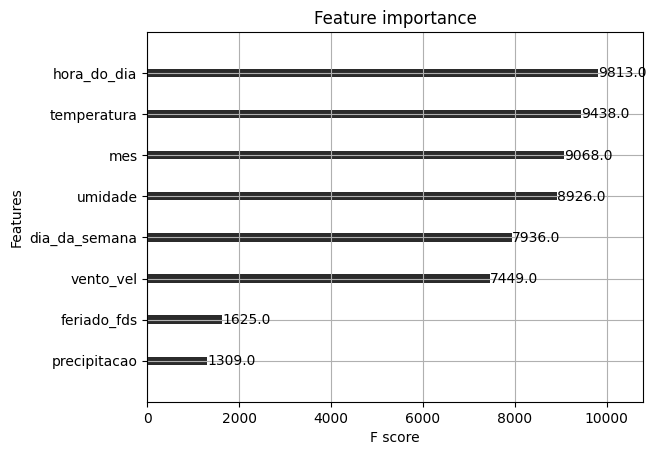

In [31]:
# Plota a importância dos parâmetros
sns.set_palette("Greys_r")
plot_importance(modelo_xgb)
plt.show()

In [32]:
# Agrupa por mês

df_agrupado = teste_agg.groupby('mes').agg(
        demanda_corridas=('demanda_corridas', 'sum'),
        previsao_demanda=('previsao_demanda', 'sum')
    ).reset_index()

In [33]:
df_agrupado.head(5)

,mes,demanda_corridas,previsao_demanda
0,1,57441,57922.0
1,2,56621,59854.0
2,3,54113,57847.0
3,4,58167,63400.0
4,5,55401,57298.0


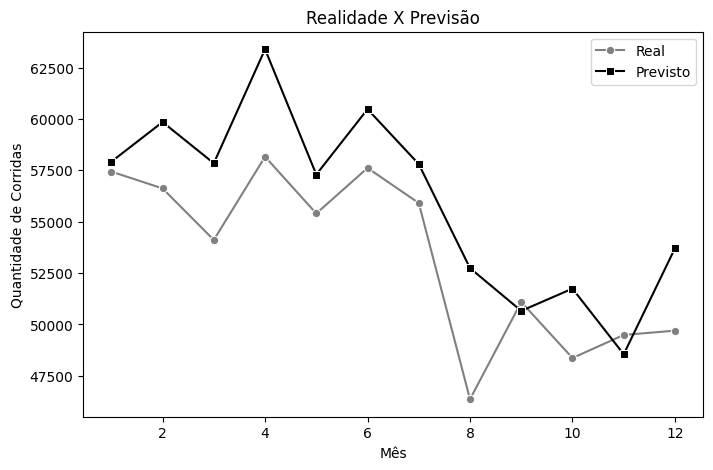

In [34]:
# Plota gráfico agrupado por mês

# Configura o tamanho do gráfico
plt.figure(figsize=(8, 5))

# Plota a primeira linha
sns.lineplot(data=df_agrupado, x='mes', y='demanda_corridas', label='Real', marker='o', color='gray')

# Plota a segunda linha
sns.lineplot(data=df_agrupado, x='mes', y='previsao_demanda', label='Previsto', marker='s', color='black')

# Título e rótulos
plt.title('Realidade X Previsão')
plt.ylabel('Quantidade de Corridas')
plt.xlabel('Mês')

# Mostra o gráfico
plt.show()

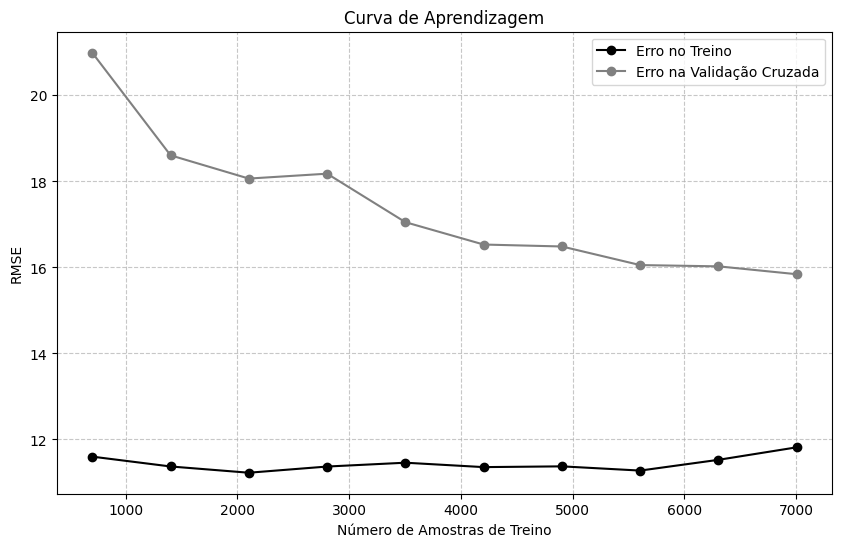

In [35]:
# Plota a curva de aprendizado
tamanhos_treino, erros_treino, erros_teste = learning_curve(
    estimator=modelo_xgb,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)


erros_treino_media = -np.mean(erros_treino, axis=1)
erros_teste_media = -np.mean(erros_teste, axis=1)

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(tamanhos_treino, erros_treino_media, 'o-', color='black', label='Erro no Treino')
plt.plot(tamanhos_treino, erros_teste_media, 'o-', color='gray', label='Erro na Validação Cruzada')

plt.title('Curva de Aprendizagem')
plt.xlabel('Número de Amostras de Treino')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [36]:
def plotar_mapa_calor(df, coluna_data, coluna_alvo):
    df_temp = df.copy()
    
    # Extrai hora e dia da semana
    df_temp['hora'] = df_temp[coluna_data].dt.hour
    df_temp['dia_semana'] = df_temp[coluna_data].dt.day_name()
    
    # Ordena os dias da semana
    ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df_temp['dia_semana'] = pd.Categorical(df_temp['dia_semana'], categories=ordem_dias, ordered=True)
    
    heatmap_data = df_temp.pivot_table(
        index='dia_semana', 
        columns='hora', 
        values=coluna_alvo, 
        aggfunc='mean'
    )
    
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap='Greys', linewidths=.5, annot=False)
    plt.title(f'Mapa de Calor: Média de {coluna_alvo} por Dia e Hora')
    plt.xlabel('Hora do Dia (0-23)')
    plt.ylabel('Dia da Semana')
    plt.tight_layout()
    plt.show()

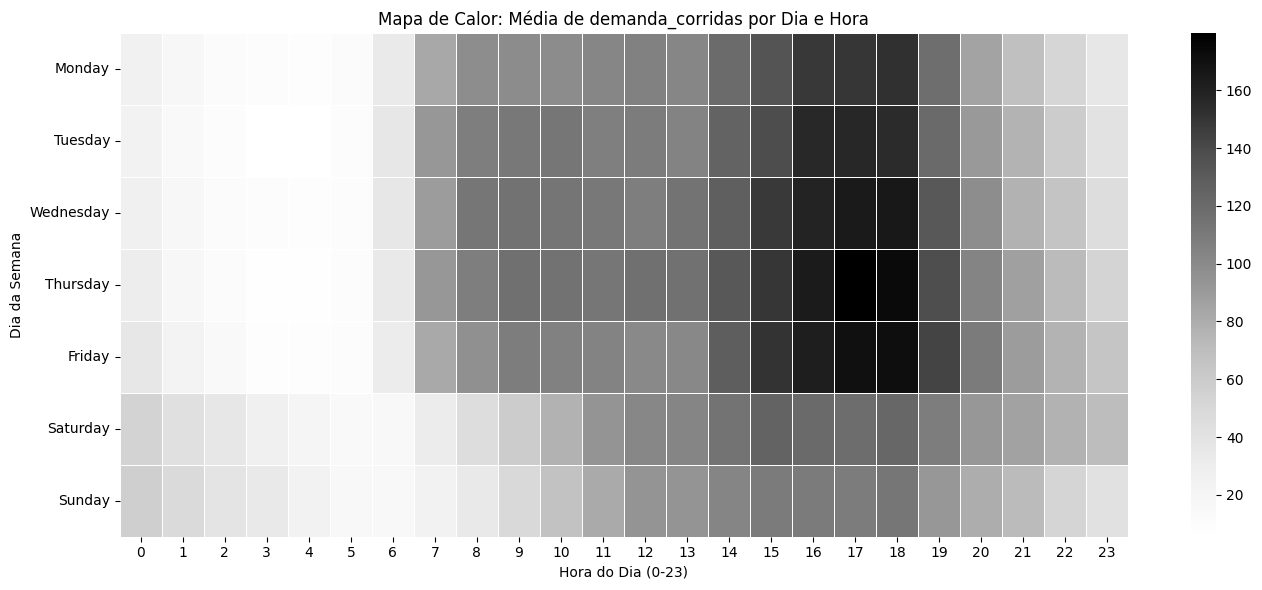

In [37]:
plotar_mapa_calor(df=teste_agg, coluna_data='data_hora', coluna_alvo='demanda_corridas')

In [38]:
def plotar_dispersao_real_vs_previsto(y_real, y_previsto):
    plt.figure(figsize=(10, 10))
    
    # Plota os pontos
    sns.scatterplot(x=y_real, y=y_previsto, alpha=0.4, color='gray', edgecolor=None)
    
    # Calcula os limites para desenhar a linha diagonal perfeita
    min_val = min(np.min(y_real), np.min(y_previsto))
    max_val = max(np.max(y_real), np.max(y_previsto))
    
    # Desenha a linha de identidade (y = x)
    plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Previsão Perfeita (y = x)')
    
    plt.title('Comparação: Volume de Corridas Real vs. Previsto')
    plt.xlabel('Volume Real de Corridas')
    plt.ylabel('Volume Previsto pelo Modelo')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


def plotar_serie_temporal_comparativa(datas, y_real, y_previsto, num_registos=336):
    plt.figure(figsize=(15, 6))
    
    # Seleciona um intervalo de dados para ficar legível
    datas_fatia = datas[:num_registos]
    y_real_fatia = y_real[:num_registos]
    y_previsto_fatia = y_previsto[:num_registos]
    
    # Plota as duas linhas
    sns.lineplot(x=datas_fatia, y=y_real_fatia, color='black', label='Volume Real', linewidth=2)
    sns.lineplot(x=datas_fatia, y=y_previsto_fatia, color='gray', label='Volume Previsto', linestyle='--', linewidth=2)
    
    plt.title('Série Temporal: Real vs. Previsto (Recorte de 14 Dias)')
    plt.xlabel('Data e Hora')
    plt.ylabel('Volume de Corridas')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



def plotar_distribuicao_residuos(y_real, y_previsto):
    # Calcula os erros
    residuos = y_real - y_previsto
    
    plt.figure(figsize=(10, 6))
    
    # Plota o histograma com a curva de densidade
    sns.histplot(residuos, bins=50, kde=True, color='purple')
    
    # Linha vertical no zero onde o erro é nulo
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erro Zero')
    
    plt.title('Distribuição dos Resíduos (Erros de Predição)')
    plt.xlabel('Erro (Volume Real - Volume Previsto)')
    plt.ylabel('Frequência (Nº de Horas)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

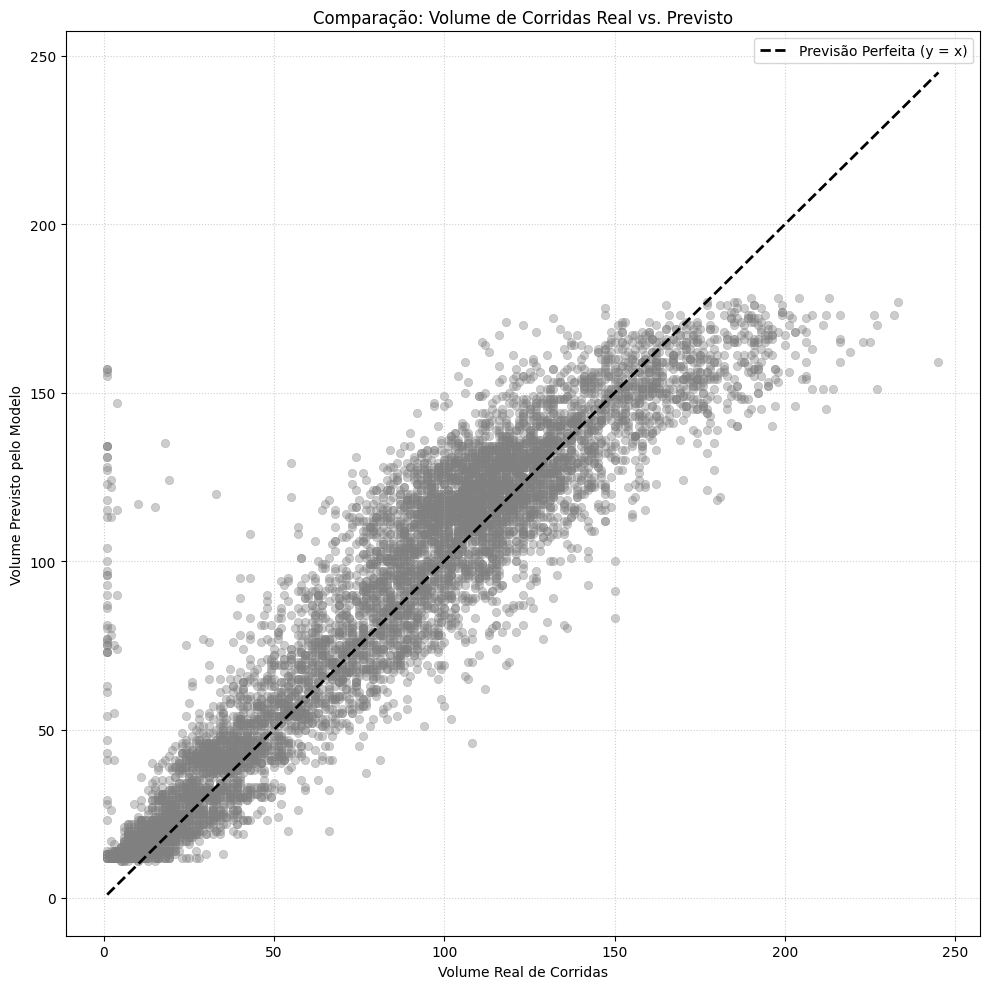

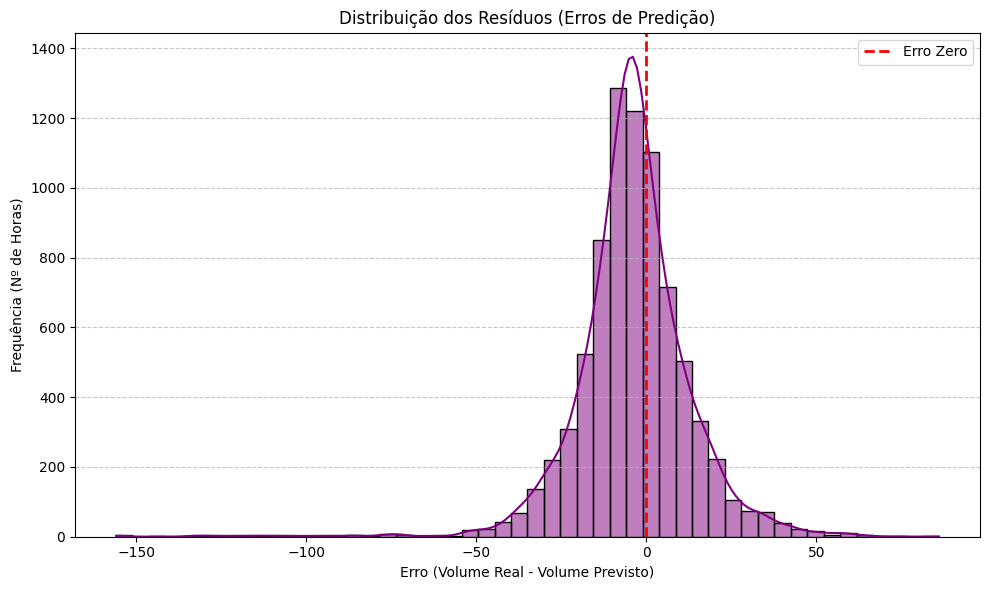

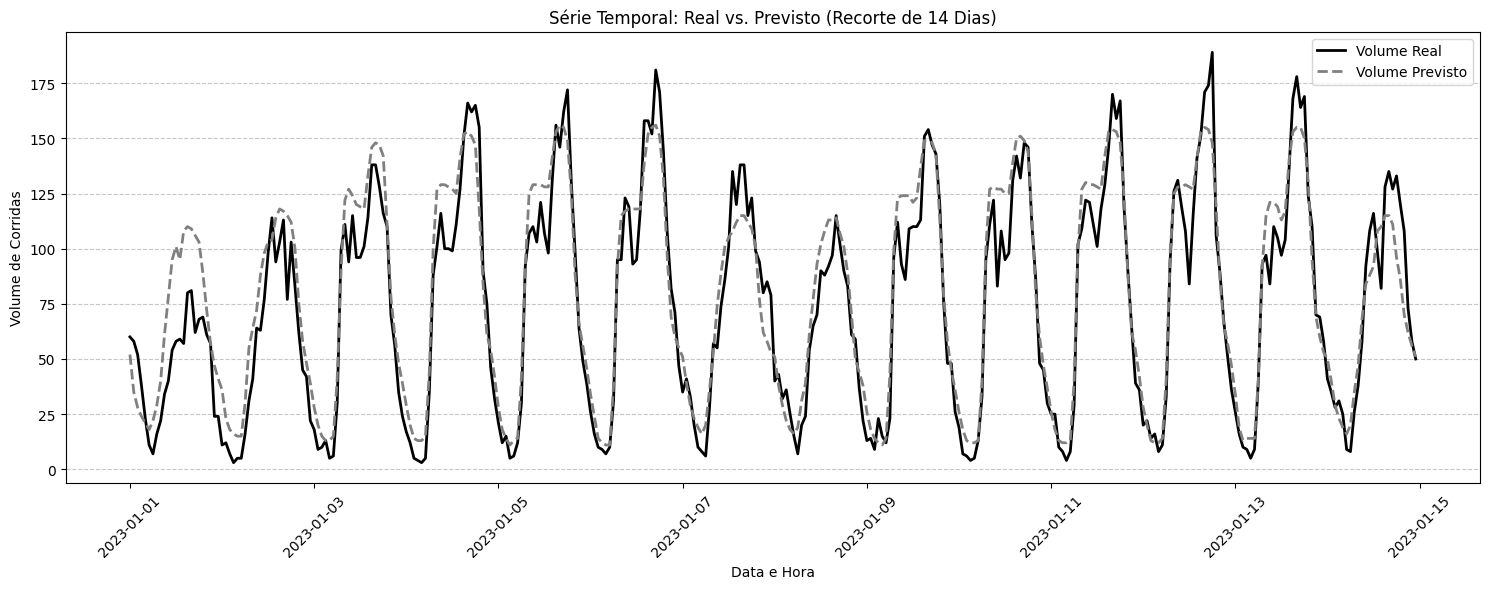

In [39]:
plotar_dispersao_real_vs_previsto(y_real=teste_agg['demanda_corridas'], y_previsto=valores_previstos )

plotar_distribuicao_residuos(y_real=teste_agg['demanda_corridas'], y_previsto=valores_previstos )

plotar_serie_temporal_comparativa(datas=teste_agg['data_hora'], y_real=y_test, y_previsto=valores_previstos )

In [40]:
def plotar_erro_por_hora(df_teste, coluna_data, y_real, y_previsto):
    df_temp = pd.DataFrame({
        'data_hora': df_teste[coluna_data].reset_index(drop=True),
        'real': y_real,
        'previsto': y_previsto
    })
    
    # Extrai a hora e calcula o erro absoluto
    df_temp['hora'] = df_temp['data_hora'].dt.hour
    df_temp['erro_absoluto'] = np.abs(df_temp['real'] - df_temp['previsto'])
    
    # Agrupa por hora calculando a média do erro
    erro_horario = df_temp.groupby('hora')['erro_absoluto'].mean().reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=erro_horario, 
        x='hora', 
        y='erro_absoluto', 
        hue='hora', 
        palette='gray', 
        legend=False
    )
    
    plt.title('Erro Absoluto Médio (MAE) por Hora do Dia')
    plt.xlabel('Hora do Dia (0-23)')
    plt.ylabel('Erro Absoluto Médio (Viagens)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()



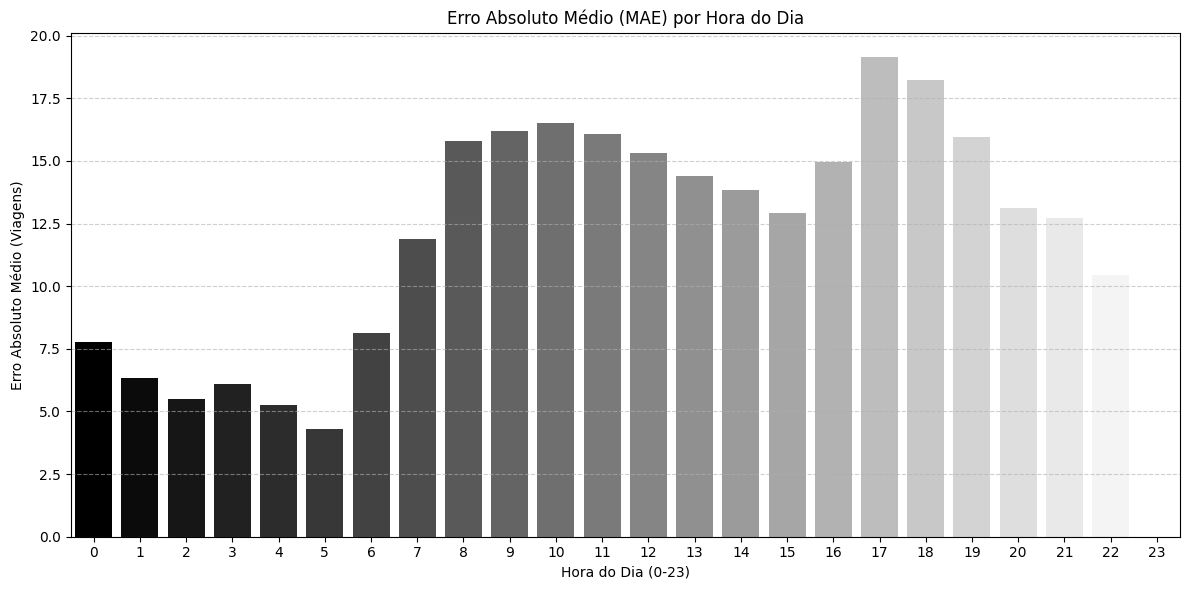

In [41]:
plotar_erro_por_hora(teste_agg, 'data_hora', teste_agg['demanda_corridas'], valores_previstos)


In [42]:
def plotar_erro_por_mes(df_teste, coluna_data, y_real, y_previsto):
    df_temp = pd.DataFrame({
        'data_hora': df_teste[coluna_data].reset_index(drop=True),
        'real': y_real,
        'previsto': y_previsto
    })
    
    # Extrai o mês
    df_temp['mes'] = df_temp['data_hora'].dt.month
    df_temp['erro_absoluto'] = np.abs(df_temp['real'] - df_temp['previsto'])
    
    # Agrupa por mês calculando a média do erro
    erro_mensal = df_temp.groupby('mes')['erro_absoluto'].mean().reset_index()
    
    # Mapeia os números para nomes dos meses
    nomes_meses = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun', 
                   7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}
    erro_mensal['nome_mes'] = erro_mensal['mes'].map(nomes_meses)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=erro_mensal, 
        x='nome_mes', 
        y='erro_absoluto', 
        hue='nome_mes', 
        palette='gray', 
        legend=False
    )
    
    plt.title('Erro Absoluto Médio (MAE) das Previsões por Mês')
    plt.xlabel('Mês do Ano')
    plt.ylabel('Erro Absoluto Médio (Viagens)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()



def plotar_comparacao_mensal(df_teste, coluna_data, y_real, y_previsto):
    df_temp = pd.DataFrame({
        'data_hora': df_teste[coluna_data].reset_index(drop=True),
        'Real': y_real,
        'Previsto': y_previsto
    })
    
    df_temp['mes'] = df_temp['data_hora'].dt.month
    
    # Agrupa por mês e soma o volume total de corridas
    mensal_agg = df_temp.groupby('mes')[['Real', 'Previsto']].sum().reset_index()
    
    nomes_meses = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun', 
                   7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}
    mensal_agg['nome_mes'] = mensal_agg['mes'].map(nomes_meses)
    
    mensal_melt = pd.melt(mensal_agg, id_vars=['mes', 'nome_mes'], 
                          value_vars=['Real', 'Previsto'], 
                          var_name='Tipo', value_name='Volume')
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=mensal_melt.sort_values('mes'), 
        x='nome_mes', 
        y='Volume', 
        hue='Tipo', 
        palette={'Real': "#989898", 'Previsto': "#363636"} # Azul escuro para o real, vermelho para o previsto
    )
    
    plt.title('Comparação do Volume Total de Corridas: Real vs. Previsto por Mês')
    plt.xlabel('Mês')
    plt.ylabel('Volume Total de Corridas')
    plt.legend(title='Dado')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

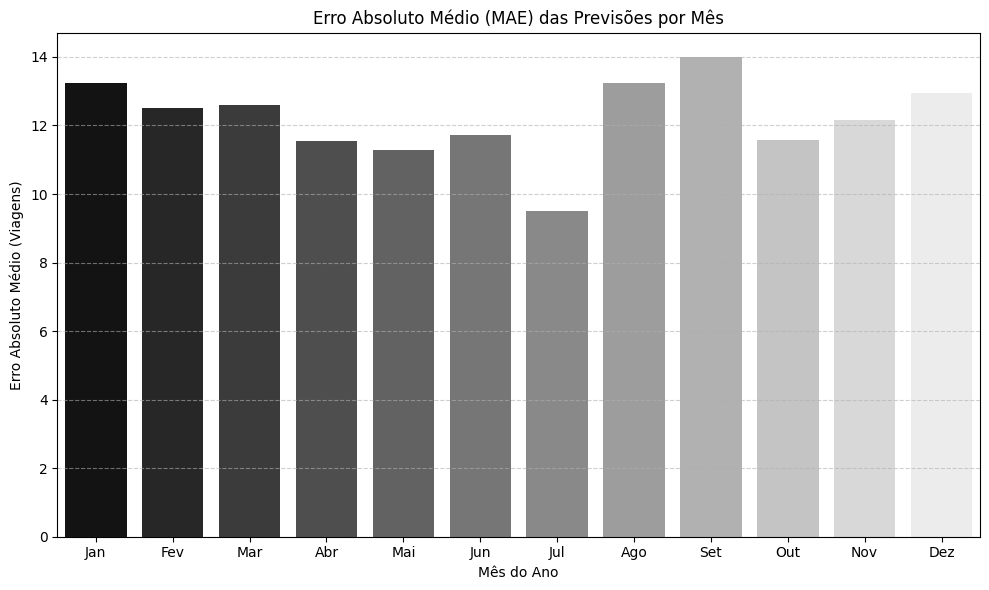

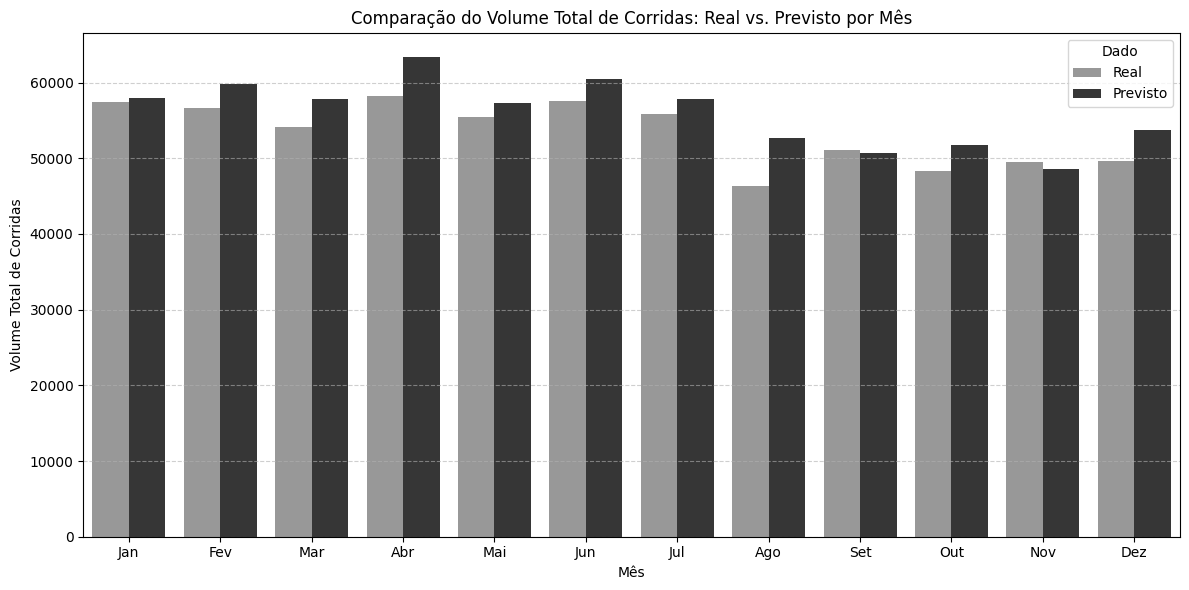

In [43]:

plotar_erro_por_mes(teste_agg, 'data_hora', teste_agg['demanda_corridas'].values, valores_previstos)


plotar_comparacao_mensal(teste_agg, 'data_hora', teste_agg['demanda_corridas'].values, valores_previstos)